# 03 — Cluster characterization and statistical comparison

This notebook loads the clustered seizure event table and compares cluster properties across KMeans, hierarchical, and GMM clustering.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway, kruskal
from sklearn.metrics import adjusted_rand_score

pd.set_option("display.max_columns", None)

output_dir = Path("../outputs/seizure_analysis")
fig_dir = output_dir / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

clustered_path = output_dir / "seizure_events_clustered.csv"
df = pd.read_csv(clustered_path)

feature_cols = [
    "amplitude",
    "FWHM",
    "prominence",
    "AUC",
    "rise",
    "decay",
    "duration"
]

cluster_cols = [
    "kmeans_cluster",
    "hierarchical_cluster",
    "gmm_cluster"
]

print(df.shape)
display(df.head())

(527, 17)


,source_row,event_id,animal,condition,stage,total_seizures_block,rate_per_min_block,amplitude,FWHM,prominence,AUC,rise,decay,duration,kmeans_cluster,hierarchical_cluster,gmm_cluster
0,2,0,M15,Sham,pre_CSD,NaN,NaN,0.302681,33.075968,0.141533,6.985217,10.866667,18.133333,29.0,1,4,1
1,3,1,M15,Sham,pre_CSD,NaN,NaN,0.371592,23.434801,0.155423,11.690090,16.705882,23.294118,40.0,1,4,1
2,5,2,M15,Sham,pre_CSD,32.0,NaN,0.337297,67.073719,0.155680,6.692575,11.136364,10.863636,22.0,1,2,1
3,7,3,M15,Sham,pre_CSD,32.0,3.48,0.362338,88.324374,0.183587,11.269923,23.448718,11.551282,35.0,1,2,1
4,8,4,M15,Sham,pre_CSD,32.0,3.48,0.299253,72.903872,0.132350,6.030345,9.695652,15.304348,25.0,1,2,1


In [2]:
for cluster_col in cluster_cols:
    print("\n", cluster_col)
    display(df[cluster_col].value_counts().sort_index().rename("n_events"))

    display(pd.crosstab(df[cluster_col], df["condition"]))
    display(pd.crosstab(df[cluster_col], df["stage"]))


 kmeans_cluster


kmeans_cluster
1     92
2     52
3    381
4      2
Name: n_events, dtype: int64

condition,CCI,Sham,Unknown
kmeans_cluster,,,
1,47,24,21
2,41,11,0
3,183,95,103
4,2,0,0


stage,post_CSD,pre_CSD
kmeans_cluster,,
1,64,28
2,33,19
3,259,122
4,1,1



 hierarchical_cluster


...

stage,post_CSD,pre_CSD
hierarchical_cluster,,
1,48,26
2,32,15
3,1,1
4,276,128



 gmm_cluster


gmm_cluster
1    203
2    287
3      1
4     36
Name: n_events, dtype: int64

condition,CCI,Sham,Unknown
gmm_cluster,,,
1,137,56,10
2,122,70,95
3,1,0,0
4,13,4,19


stage,post_CSD,pre_CSD
gmm_cluster,,
1,144,59
2,183,104
3,1,0
4,29,7


In [3]:
summary_tables = {}

for cluster_col in cluster_cols:

    summary = (
        df
        .groupby(cluster_col)[feature_cols]
        .agg(["count", "mean", "std", "median", "min", "max"])
        .round(4)
    )

    summary_tables[cluster_col] = summary

    out_path = output_dir / f"{cluster_col}_feature_summary.csv"
    summary.to_csv(out_path)

    print("Saved:", out_path)
    display(summary)

Saved: ../outputs/seizure_analysis/kmeans_cluster_feature_summary.csv


amplitude                                          FWHM  \
                   count    mean     std  median     min     max count   
kmeans_cluster                                                           
1                     92  0.3574  0.1671  0.3279  0.1282  0.8336    92   
2                     52  0.2946  0.2573  0.1902  0.0460  1.1406    52   
3                    381  0.1808  0.1396  0.1397  0.0210  0.7995   381   
4                      2  4.6039  1.8569  4.6039  3.2909  5.9169     2   

                                                            prominence  \
                   mean      std   median      min      max      count   
kmeans_cluster                                                           
1               31.0717  15.9364  26.9642  11.8413  88.3244         92   
2               31.0548  17.1810  26.5988  11.6601  98.2072         52   
3               13.5842   5.2217  12.9807   2.3335  33.1340        381   
4               24.1718  23.1878  24.1718   7.7756  40.5681          2   

                                                         AUC            \
                  mean     std  median     min     max count      mean   
kmeans_cluster                                                           
1               0.1976  0.1231  0.1556  0.0454  0.5276    92   11.1319   
2               0.1336  0.1692  0.0744  0.0140  0.8537    52   27.0010   
3               0.0551  0.0348  0.0470  0.0070  0.1813   381    4.7494   
4               0.4476  0.4932  0.4476  0.0989  0.7964     2  450.8695   

                                                        rise           \
                     std    median       min       max count     mean   
kmeans_cluster                                                          
1                 7.3786    9.4963    3.3236   49.6706    92  21.7057   
2                25.7627   16.8923    3.8642  127.2358    52  62.9305   
3                 4.6522    3.3815    0.2115   36.2397   381  15.2386   
4               364.6792  450.8695  193.0024  708.7366     2  65.5061   

                                                    decay                     \
                    std   median      min       max count     mean       std   
kmeans_cluster                                                                 
1               10.4559  19.7427   5.1667   57.4037    92  23.0552    9.5373   
2               19.8408  58.7735  24.6743  127.4494    52  60.9541   20.3465   
3                8.0732  13.1149   1.0330   43.5571   381  16.4149    7.7948   
4               64.0923  65.5061  20.1860  110.8262     2  85.4939  102.7849   

                                           duration                      \
                 median      min       max    count      mean       std   
kmeans_cluster                                                            
1               22.2451   7.5039   50.4399       92   44.7609   17.4642   
2               55.2615  21.2361  130.2198       52  123.8846   34.5178   
3               14.8092   1.4957   42.6961      381   31.6535   15.1232   
4               85.4939  12.8140  158.1738        2  151.0000  166.8772   

                                    
               median   min    max  
kmeans_cluster                      
1                42.5  16.0   82.0  
2               110.0  86.0  214.0  
3                28.0   5.0   82.0  
4               151.0  33.0  269.0

Saved: ../outputs/seizure_analysis/hierarchical_cluster_feature_summary.csv


amplitude                                          FWHM  \
                         count    mean     std  median     min     max count   
hierarchical_cluster                                                           
1                           74  0.2362  0.2118  0.1706  0.0460  1.1406    74   
2                           47  0.4080  0.1790  0.4120  0.1592  0.8336    47   
3                            2  4.6039  1.8569  4.6039  3.2909  5.9169     2   
4                          404  0.1991  0.1522  0.1504  0.0210  0.8211   404   

                                                                  prominence  \
                         mean      std   median      min      max      count   
hierarchical_cluster                                                           
1                     26.0967  13.6890  23.2060   7.6362  74.6608         74   
2                     38.3827  21.4781  34.3369  11.8413  98.2072         47   
3                     24.1718  23.1878  24.1718   7.7756  40.5681          2   
4                     14.6383   6.4365  13.5656   2.3335  41.4745        404   

                                                               AUC            \
                        mean     std  median     min     max count      mean   
hierarchical_cluster                                                           
1                     0.0982  0.1413  0.0655  0.0081  0.8537    74   20.4724   
2                     0.2548  0.1466  0.2408  0.0736  0.5276    47   15.1772   
3                     0.4476  0.4932  0.4476  0.0989  0.7964     2  450.8695   
4                     0.0665  0.0492  0.0542  0.0070  0.2720   404    4.9739   

                                                              rise           \
                           std    median       min       max count     mean   
hierarchical_cluster                                                          
1                      22.6306   11.9631    3.7211  127.2358    74  54.6427   
2                      12.3936   10.9928    3.3876   52.6084    47  24.0165   
3                     364.6792  450.8695  193.0024  708.7366     2  65.5061   
4                       4.6319    3.5518    0.2115   36.2397   404  14.6111   

                                                          decay           \
                          std   median      min       max count     mean   
hierarchical_cluster                                                       
1                     20.9602  49.8456  24.6743  127.4494    74  52.8708   
2                     11.1792  23.1323   8.5517   57.4037    47  25.7707   
3                     64.0923  65.5061  20.1860  110.8262     2  85.4939   
4                      7.1176  12.8491   1.0330   35.8651   404  15.8938   

                                                           duration            \
                           std   median      min       max    count      mean   
hierarchical_cluster                                                            
1                      20.9931  47.7662  21.2361  130.2198       74  107.5135   
2                      11.1901  23.0875  10.8636   62.7006       47   49.7872   
3                     102.7849  85.4939  12.8140  158.1738        2  151.0000   
4                       6.8997  14.7892   1.4957   41.4062      404   30.5050   

                                                    
                           std median   min    max  
hierarchical_cluster                                
1                      38.2820   98.5  56.0  214.0  
2                      19.3592   50.0  20.0   96.0  
3                     166.8772  151.0  33.0  269.0  
4                      12.9436   28.0   5.0   64.0

Saved: ../outputs/seizure_analysis/gmm_cluster_feature_summary.csv


amplitude                                          FWHM           \
                count    mean     std  median     min     max count     mean   
gmm_cluster                                                                    
1                 203  0.3154  0.1791  0.2832  0.0460  0.8336   203  23.9995   
2                 287  0.1248  0.0488  0.1177  0.0210  0.2646   287  13.7050   
3                   1  5.9169     NaN  5.9169  5.9169  5.9169     1   7.7756   
4                  36  0.5703  0.5167  0.4954  0.0543  3.2909    36  24.5661   

                                               prominence                  \
                 std   median     min      max      count    mean     std   
gmm_cluster                                                                 
1            15.9065  19.9016  2.4387  98.2072        203  0.1011  0.0635   
2             5.1708  13.0038  2.3335  27.8803        287  0.0479  0.0293   
3                NaN   7.7756  7.7756   7.7756          1  0.0989     NaN   
4            15.2482  18.4728  6.4587  64.2816         36  0.3513  0.1981   

                                      AUC                                \
             median     min     max count      mean       std    median   
gmm_cluster                                                               
1            0.0903  0.0081  0.4384   203   10.9722    7.3171    9.0351   
2            0.0403  0.0070  0.1348   287    3.1311    1.7714    2.6576   
3            0.0989  0.0989  0.0989     1  193.0024       NaN  193.0024   
4            0.3310  0.0171  0.8537    36   50.5690  116.6456   14.3429   

                                 rise                                      \
                  min       max count     mean      std   median      min   
gmm_cluster                                                                 
1              0.9321   47.6979   203  26.4208  20.2207  18.5565   1.3714   
2              0.2115    9.1486   287  15.4729   7.6386  13.3462   1.0330   
3            193.0024  193.0024     1  20.1860      NaN  20.1860  20.1860   
4              5.3681  708.7366    36  38.3864  34.6748  23.0582   7.4848   

                      decay                                                \
                  max count     mean      std   median      min       max   
gmm_cluster                                                                 
1             98.1588   203  27.4659  20.1475  21.4576   3.0000  130.2198   
2             39.9626   287  16.3042   7.1842  15.0714   1.4957   37.0374   
3             20.1860     1  12.8140      NaN  12.8140  12.8140   12.8140   
4            127.4494    36  40.2247  32.8741  27.4222   6.4538  158.1738   

            duration                                        
               count     mean      std median   min    max  
gmm_cluster                                                 
1                203  53.8867  38.9300   40.0   9.0  214.0  
2                287  31.7770  14.2911   28.0   5.0   77.0  
3                  1  33.0000      NaN   33.0  33.0   33.0  
4                 36  78.6111  64.5044   51.5  16.0  269.0

In [4]:
stats_rows = []

for cluster_col in cluster_cols:

    clusters = sorted(df[cluster_col].dropna().unique())

    for feature in feature_cols:

        groups = [
            df.loc[df[cluster_col] == cluster, feature].dropna().values
            for cluster in clusters
        ]

        valid_groups = [g for g in groups if len(g) > 1]

        if len(valid_groups) >= 2:
            anova_stat, anova_p = f_oneway(*valid_groups)
            kw_stat, kw_p = kruskal(*valid_groups)
        else:
            anova_stat, anova_p, kw_stat, kw_p = np.nan, np.nan, np.nan, np.nan

        stats_rows.append({
            "clustering_method": cluster_col,
            "feature": feature,
            "anova_F": anova_stat,
            "anova_p": anova_p,
            "kruskal_H": kw_stat,
            "kruskal_p": kw_p
        })

stats_df = pd.DataFrame(stats_rows)

stats_path = output_dir / "cluster_feature_stat_tests.csv"
stats_df.to_csv(stats_path, index=False)

print("Saved:", stats_path)
display(stats_df)

Saved: ../outputs/seizure_analysis/cluster_feature_stat_tests.csv


,clustering_method,feature,anova_F,anova_p,kruskal_H,kruskal_p
0,kmeans_cluster,amplitude,424.570436,1.070445e-139,112.604848,3.017819e-24
1,kmeans_cluster,FWHM,113.711697,1.079793e-56,197.999855,1.141110e-42
2,kmeans_cluster,prominence,92.786121,3.725957e-48,169.633844,1.526557e-36
3,kmeans_cluster,AUC,401.263505,3.418609e-135,202.448907,1.247400e-43
4,kmeans_cluster,rise,319.783867,7.115775e-118,164.050295,2.448968e-35
5,kmeans_cluster,decay,273.565619,9.832892e-107,166.431891,7.497538e-36
6,kmeans_cluster,duration,353.965657,1.833079e-125,176.327199,5.477436e-38
7,hierarchical_cluster,amplitude,398.744968,1.075094e-134,66.926531,1.941678e-14
8,hierarchical_cluster,FWHM,96.758201,7.956881e-50,121.812895,3.140328e-26
9,hierarchical_cluster,prominence,83.755655,2.900097e-44,94.387918,2.499497e-20


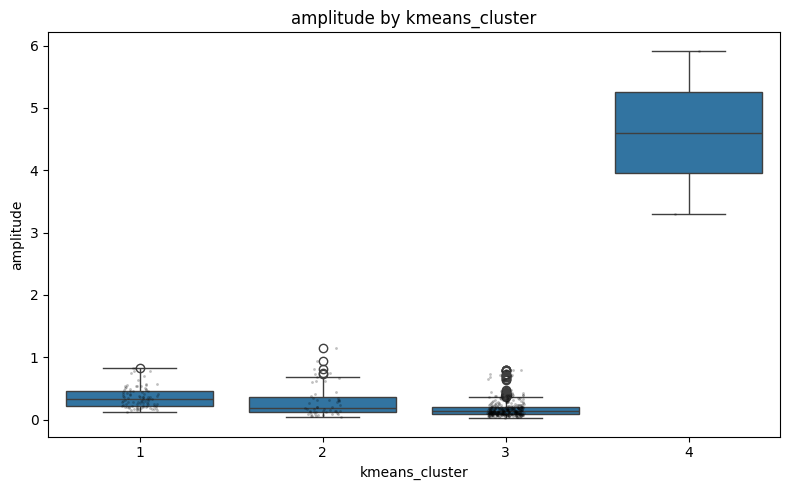

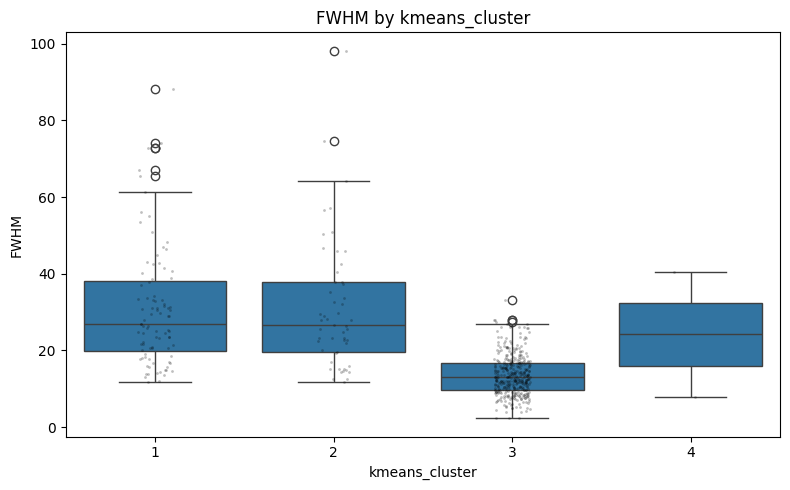

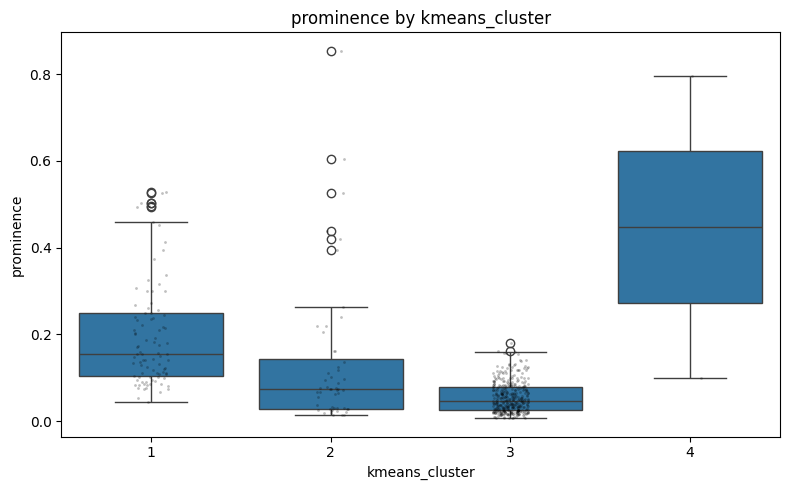

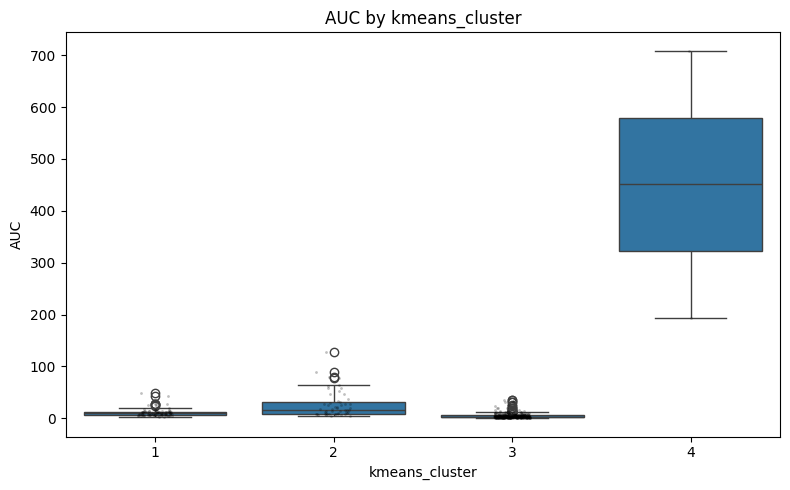

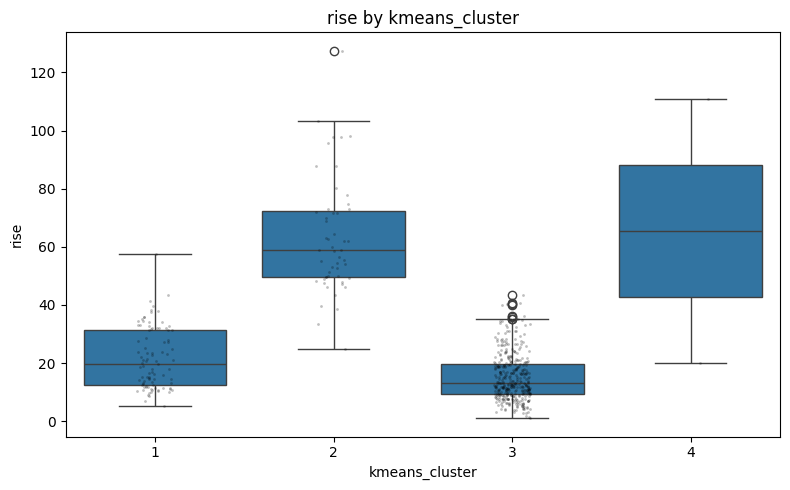

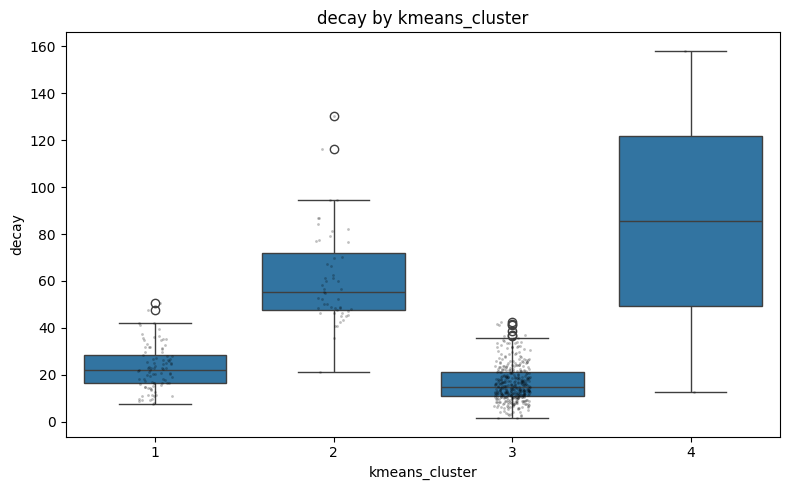

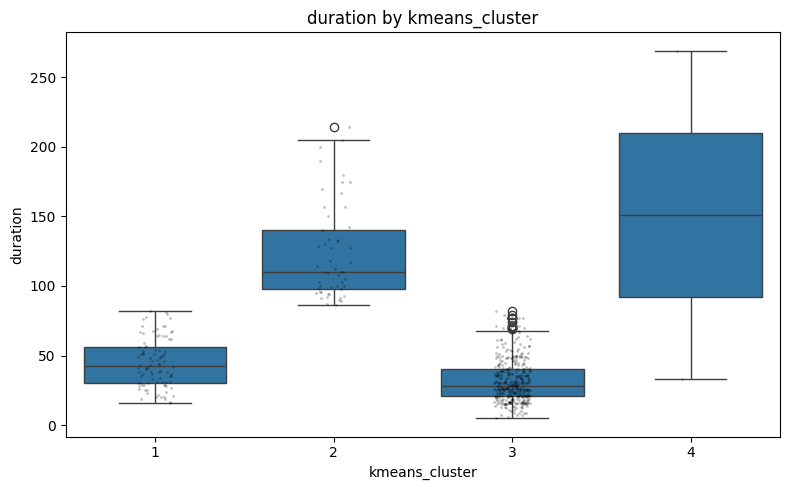

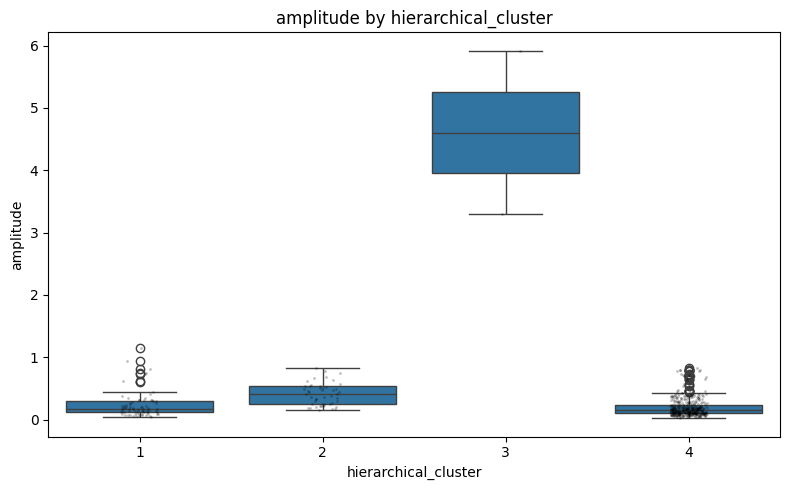

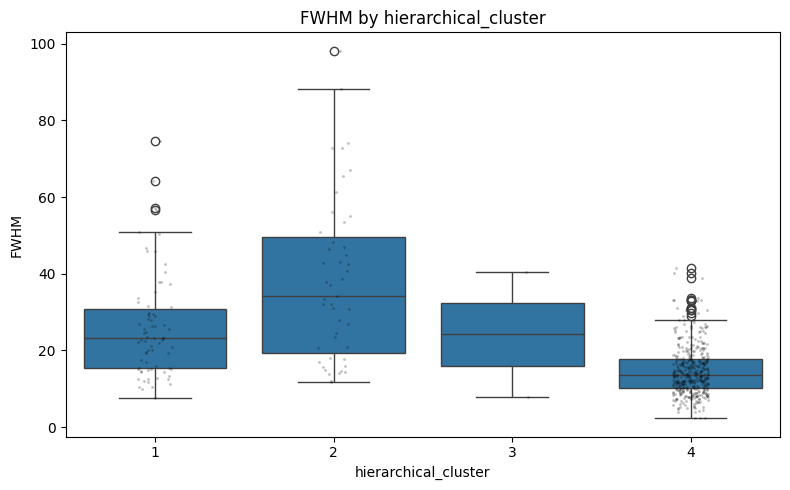

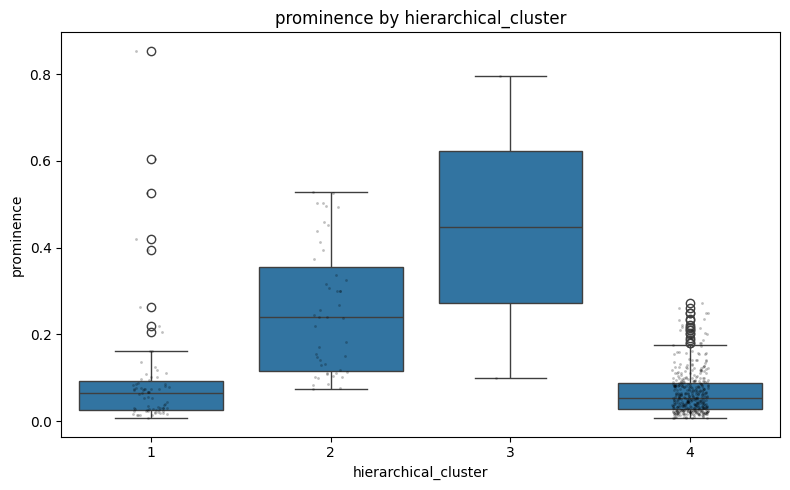

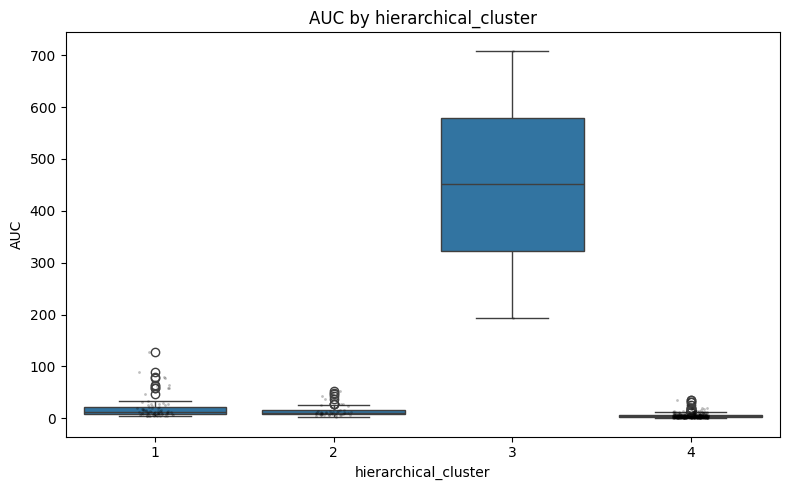

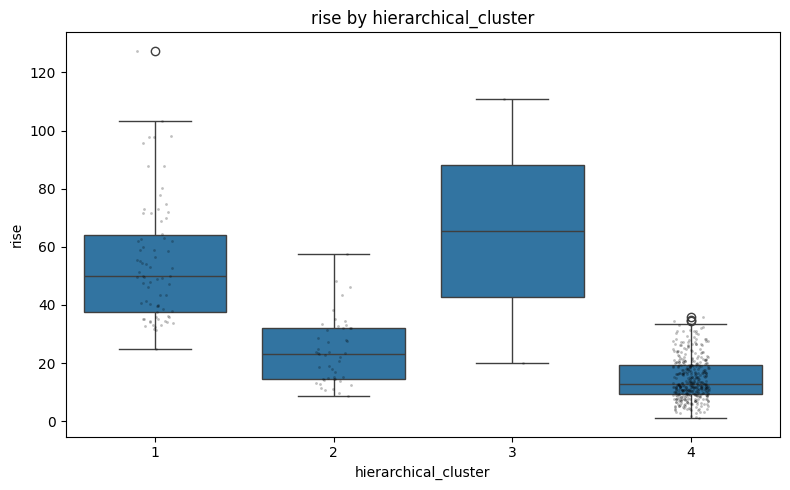

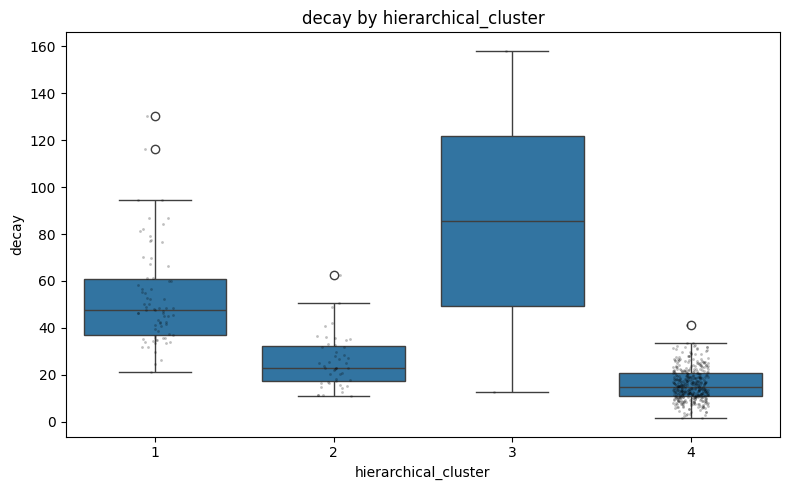

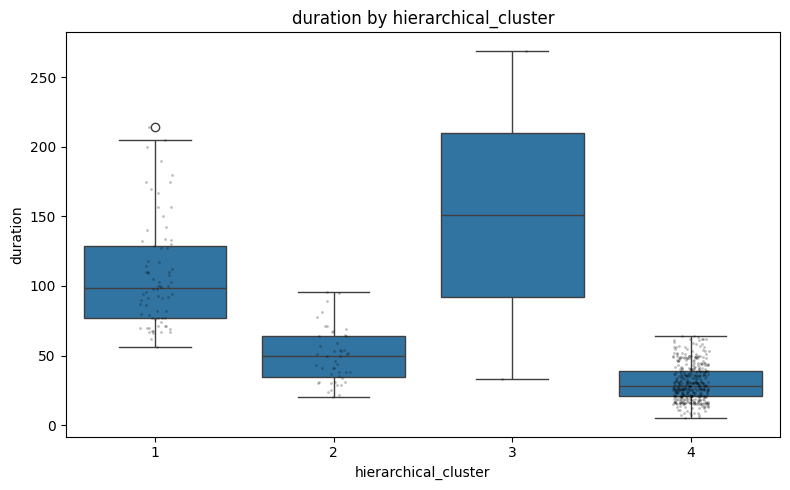

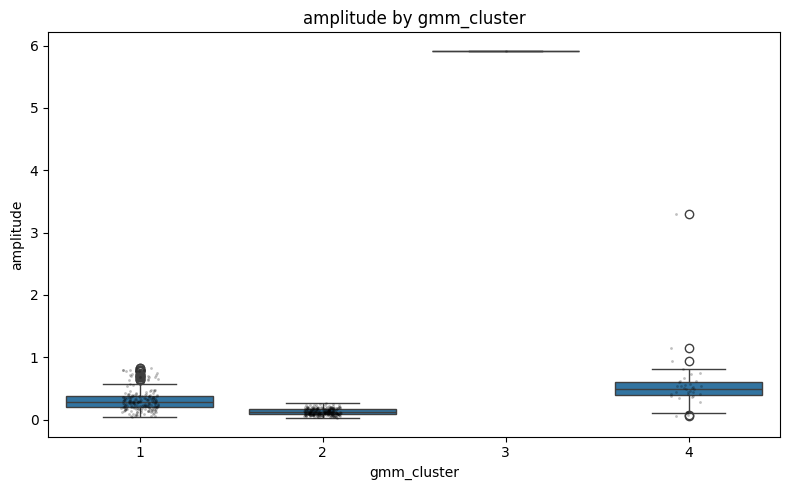

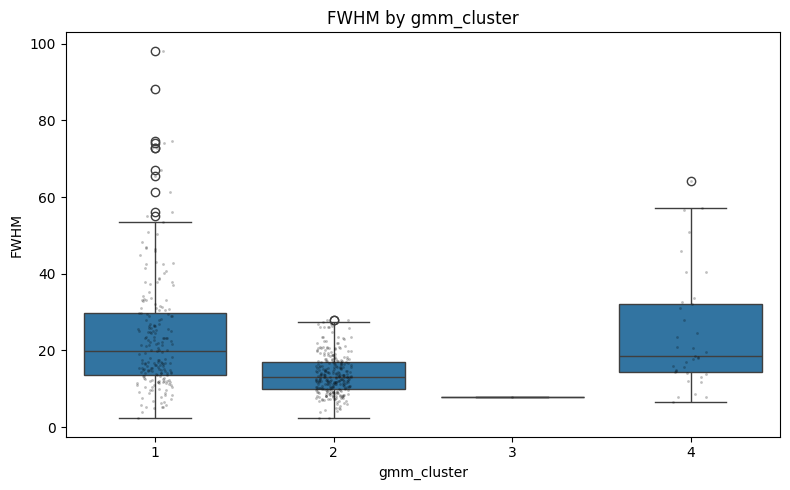

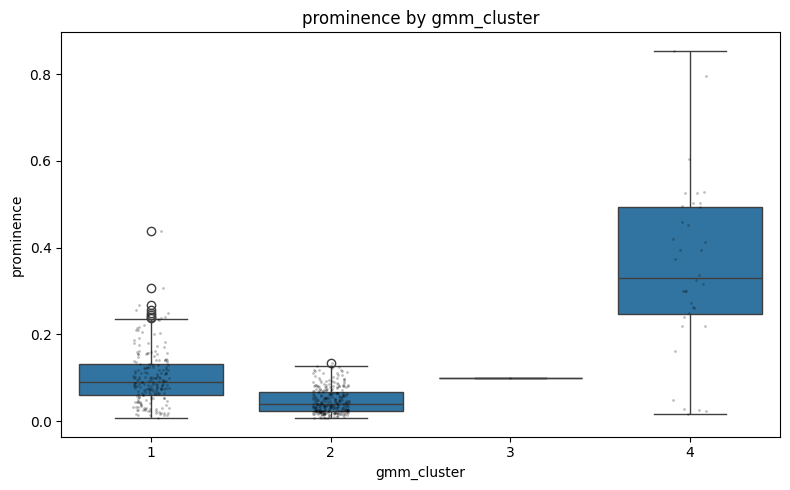

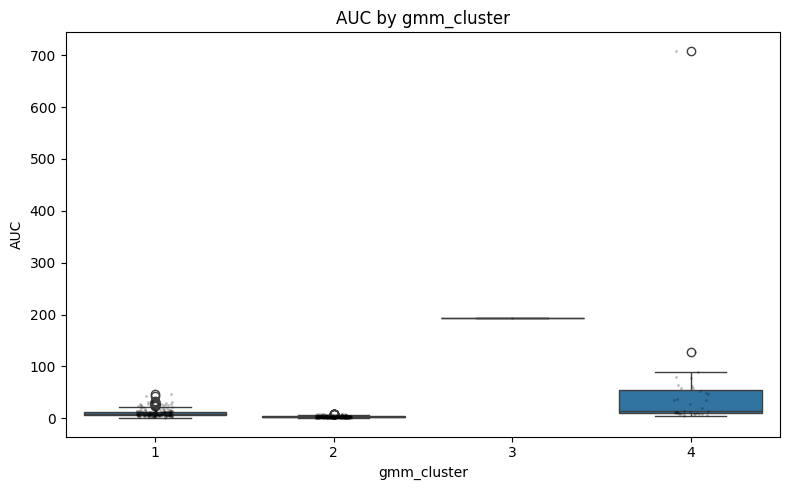

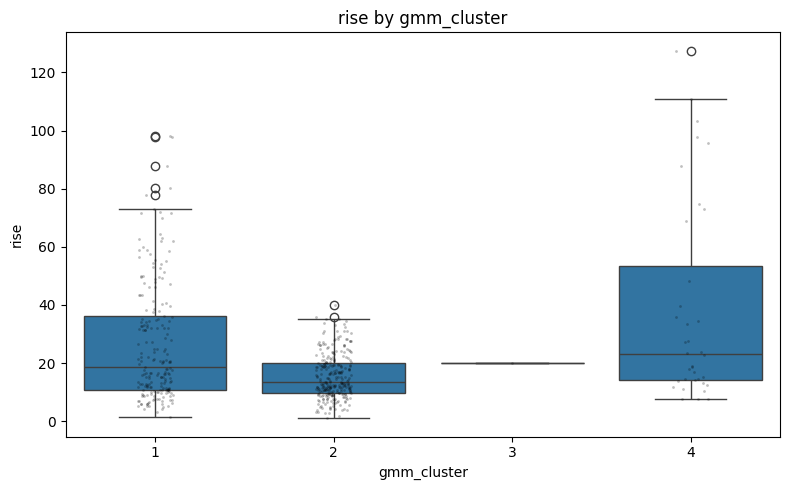

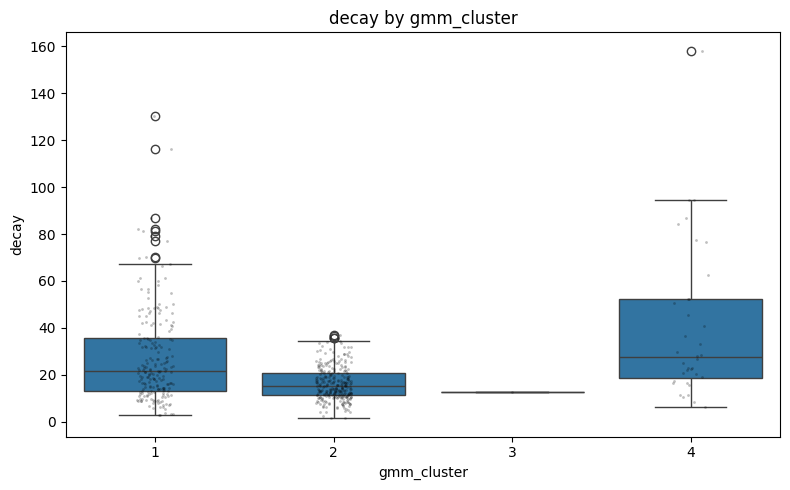

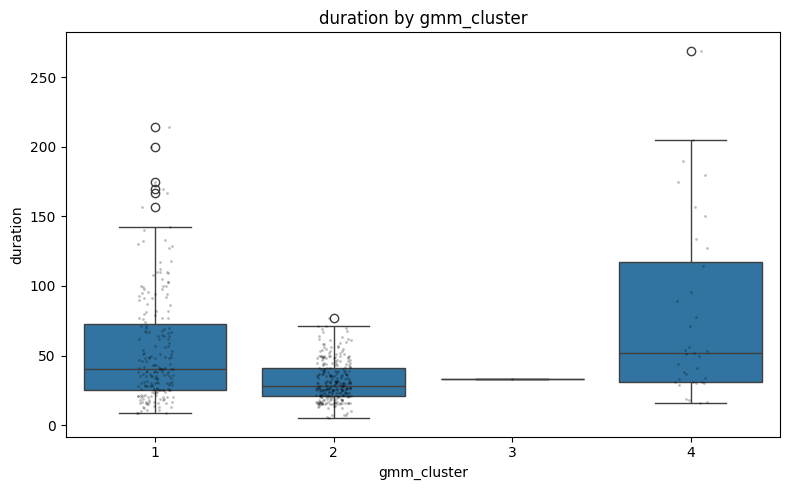

In [5]:
for cluster_col in cluster_cols:

    for feature in feature_cols:

        plt.figure(figsize=(8, 5))

        sns.boxplot(
            data=df,
            x=cluster_col,
            y=feature
        )

        sns.stripplot(
            data=df,
            x=cluster_col,
            y=feature,
            color="black",
            alpha=0.25,
            size=2
        )

        plt.title(f"{feature} by {cluster_col}")
        plt.tight_layout()

        out_path = fig_dir / f"{cluster_col}_{feature}_boxplot.tiff"
        plt.savefig(out_path, dpi=300, format="tiff")
        plt.show()


kmeans_cluster vs hierarchical_cluster


hierarchical_cluster,1,2,3,4
kmeans_cluster,,,,
1,10,44,0,38
2,49,3,0,0
3,15,0,0,366
4,0,0,2,0


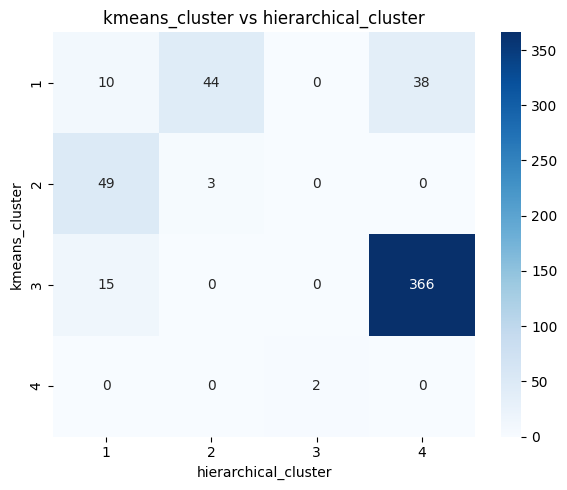


kmeans_cluster vs gmm_cluster


gmm_cluster,1,2,3,4
kmeans_cluster,,,,
1,71,1,0,20
2,41,0,0,11
3,91,286,0,4
4,0,0,1,1


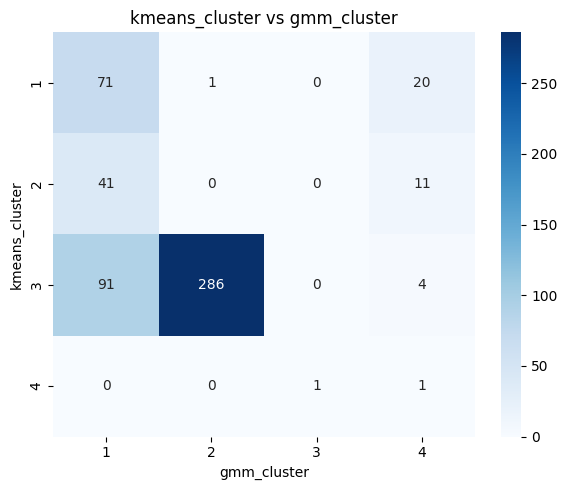


hierarchical_cluster vs gmm_cluster


gmm_cluster,1,2,3,4
hierarchical_cluster,,,,
1,58,7,0,9
2,28,0,0,19
3,0,0,1,1
4,117,280,0,7


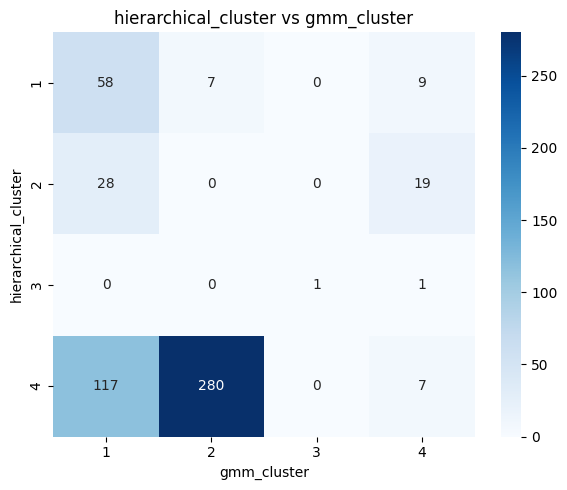

,method_A,method_B,adjusted_rand_score
0,kmeans_cluster,hierarchical_cluster,0.650310
1,kmeans_cluster,gmm_cluster,0.383559
2,hierarchical_cluster,gmm_cluster,0.279461


Saved: ../outputs/seizure_analysis/clustering_method_agreement.csv


In [6]:
ari_rows = []

for a, b in [
    ("kmeans_cluster", "hierarchical_cluster"),
    ("kmeans_cluster", "gmm_cluster"),
    ("hierarchical_cluster", "gmm_cluster")
]:

    ari_rows.append({
        "method_A": a,
        "method_B": b,
        "adjusted_rand_score": adjusted_rand_score(df[a], df[b])
    })

    ctab = pd.crosstab(df[a], df[b])
    print(f"\n{a} vs {b}")
    display(ctab)

    plt.figure(figsize=(6, 5))
    sns.heatmap(ctab, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{a} vs {b}")
    plt.tight_layout()
    plt.savefig(fig_dir / f"{a}_vs_{b}_crosstab.tiff", dpi=300, format="tiff")
    plt.show()

ari_df = pd.DataFrame(ari_rows)
ari_path = output_dir / "clustering_method_agreement.csv"
ari_df.to_csv(ari_path, index=False)

display(ari_df)
print("Saved:", ari_path)

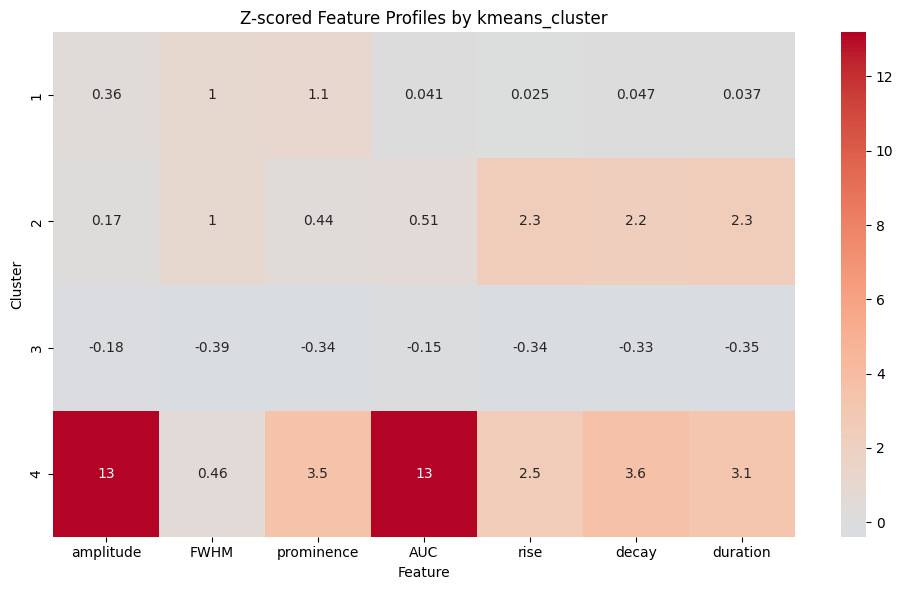

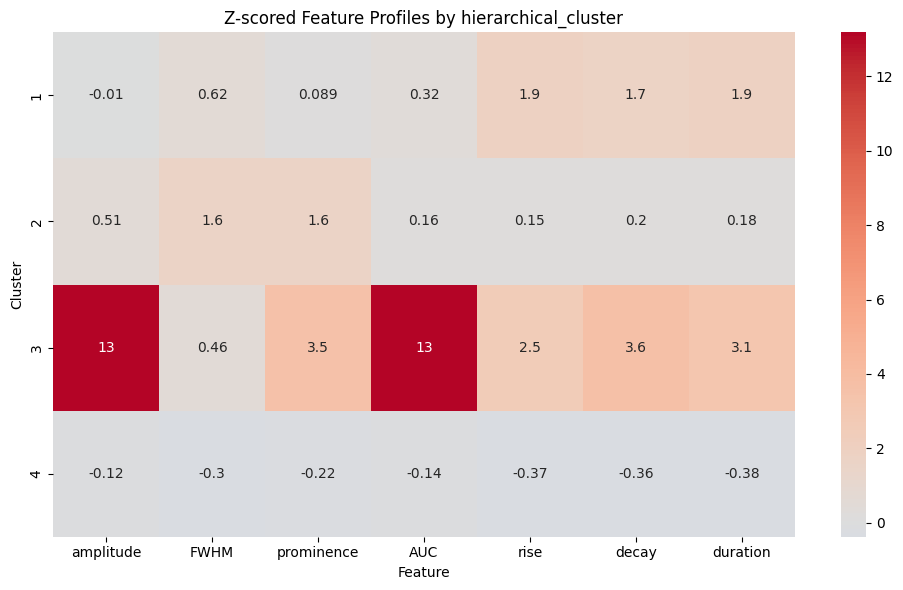

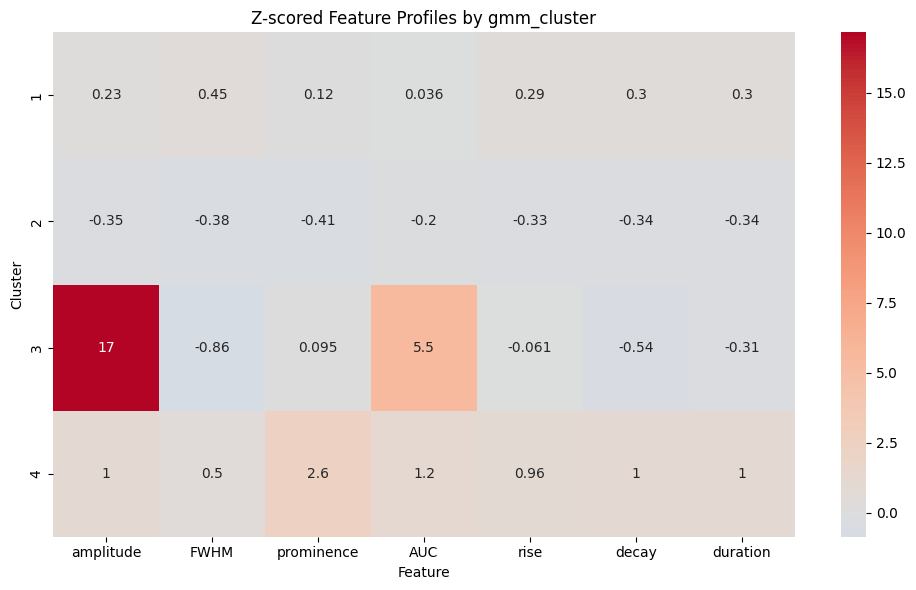

In [7]:
for cluster_col in cluster_cols:

    means = df.groupby(cluster_col)[feature_cols].mean()

    z_means = (means - df[feature_cols].mean()) / df[feature_cols].std()

    plt.figure(figsize=(10, 6))
    sns.heatmap(
        z_means,
        annot=True,
        cmap="coolwarm",
        center=0
    )

    plt.title(f"Z-scored Feature Profiles by {cluster_col}")
    plt.xlabel("Feature")
    plt.ylabel("Cluster")
    plt.tight_layout()

    out_path = fig_dir / f"{cluster_col}_zscored_feature_profiles.tiff"
    plt.savefig(out_path, dpi=300, format="tiff")
    plt.show()

In [8]:
for cluster_col in cluster_cols:

    sorted_df = df.sort_values([cluster_col, "animal", "stage", "event_id"])

    out_path = output_dir / f"seizure_events_sorted_by_{cluster_col}.csv"
    sorted_df.to_csv(out_path, index=False)

    print("Saved:", out_path)

Saved: ../outputs/seizure_analysis/seizure_events_sorted_by_kmeans_cluster.csv
Saved: ../outputs/seizure_analysis/seizure_events_sorted_by_hierarchical_cluster.csv
Saved: ../outputs/seizure_analysis/seizure_events_sorted_by_gmm_cluster.csv
